<a href="https://colab.research.google.com/github/miaowangcissy/animal_behavior_analysis_in_python/blob/main/day4_state_discovery/Day4_Project2_Celegans_PCA_and_StateSpace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# C. elegans Behavior Analysis: Part 1
## From High-Dimensional Postures to Behavioral State Spaces

**Adapted from:** Physics of Behavior Tutorials, OIST  
**Original material by:** BingKan Xue (University of Florida) and OIST Behavior Analysis Group  
**Source:** https://github.com/oist/Physics-of-Behavior-Tutorials

---

## Learning Objectives

By the end of this tutorial, you will be able to:

1. **Apply PCA to C. elegans posture data** to discover "eigenworms" - the fundamental modes of worm movement
2. **Reconstruct behavior** from low-dimensional representations
3. **Visualize behavioral state spaces** and understand how they reveal locomotion patterns
4. **Grasp the concept of delay embedding** for state-space reconstruction
5. **Apply the Maximum Predictability Principle** to find optimal representations of behavior

---

## Why Study C. elegans Behavior?

*C. elegans* is a tiny roundworm (~1mm long) that has become one of neuroscience's most powerful model organisms:
- **Exactly 302 neurons** (fully mapped connectome)
- **Stereotyped behavior** that's quantifiable and reproducible
- **Rich locomotion patterns** despite simple body plan
- **Genetically tractable** for studying neural circuits

The worm's crawling behavior contains a wealth of information about its internal state, decision-making, and neural dynamics. By analyzing posture quantitatively, we can discover fundamental principles of how nervous systems generate behavior.

---

## The Challenge: High-Dimensional Behavioral Data

When recording animal behavior with modern tracking systems, we often end up with **extremely high-dimensional data**:

- Each pixel in a video frame
- Positions of many body parts over time
- Multiple features at multiple time scales

For C. elegans, even representing the worm's posture as angles along its body gives us **100 dimensions per time point**!

**Key Question:** Are all 100 dimensions truly independent? Or does the worm's body have constraints that reduce the "true" dimensionality?

**Our Goal:** Find an automated, unbiased way to reduce dimensionality and extract the basic modes of behavior.

---

## Setup

First, let's import the libraries we'll need and set up our environment.

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as anim
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import plotly.graph_objs as go
import plotly
from scipy.integrate import odeint
from sklearn.cluster import MiniBatchKMeans
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Set plotting parameters for readability
plt.rcParams.update({'font.size': 14})
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully!")
print(f"  NumPy version: {np.__version__}")

✓ Libraries imported successfully!
  NumPy version: 2.1.3


---

# Part 1: Understanding Dimensionality Reduction with PCA

## 1.1 Recap of Principal Component Analysis (PCA)

**Principal Component Analysis (PCA)** is a dimensionality reduction technique that identifies the axes capturing the most variance in a dataset. These axes are called **principal components (PCs)**.

### Mathematical Foundation

PCA finds directions in which the variance of the data is maximized. These directions are given by the **eigenvectors** of the **covariance matrix**, and the amount of variance explained by each eigenvector is given by its associated **eigenvalue**.

For data matrix $X$ (n samples × p features):

1. **Center the data**: $X_c = X - \bar{X}$ (subtract mean of each feature)

2. **Compute covariance matrix**: 
   $$C = \frac{1}{n-1} X_c^T X_c$$

3. **Find eigenvectors and eigenvalues**:
   $$C \mathbf{v}_i = \lambda_i \mathbf{v}_i$$
   
   where $\mathbf{v}_i$ is the $i$-th principal component and $\lambda_i$ is the variance explained

4. **Project data onto PCs**:
   $$\mathbf{a}_i = X_c \mathbf{v}_i$$
   
   where $\mathbf{a}_i$ are the PC coefficients (scores)

5. **Reconstruct from K components**:
   $$\hat{X} = \sum_{k=1}^{K} \mathbf{a}_k \mathbf{v}_k^T + \bar{X}$$

### Why PCA Works for Behavioral Data

Body parts are not independent! They're connected by muscles, skeleton, and physics:
- Some variables co-vary (move together)
- PCA identifies which combinations of variables vary independently
- These independent variations are often the most informative for understanding behavior

---

## 1.2 Loading the C. elegans Posture Data

Now let's apply PCA to real behavioral data!

### How is worm posture represented?

In the experiment by [Stephens et al., 2008](https://doi.org/10.1371/journal.pcbi.1000028):
1. Worms crawl on an agar plate
2. Recorded from above at **4 frames/second**
3. A centerline is drawn along the worm's body
4. Posture is represented as **100 consecutive angles** along this centerline
<img src="attach_figure/worm_feature.png" alt="Processed image" align="middle" width="600"/>
This gives us a **100-dimensional representation** of posture at each time point.

### Why use angles instead of (x,y) coordinates?

- **Egocentric (body-centered)** representation
- **Invariant to translation and rotation** of the whole worm
- Captures the worm's **shape** independent of its position in space


In [34]:
# Load C. elegans posture data
# Each row is a time point, each column is an angle along the body
# load the data set 
!curl -sO https://raw.githubusercontent.com/miaowangcissy/animal_behavior_analysis_in_python/main/data/worm/shapes.csv

data = pd.read_csv('shapes.csv')
print("✓ Data loaded successfully!")
print(f"  Data shape: {data.shape}")
# transform the data to numpy array for easier processing
data = data.values

N, D = data.shape
frame_rate = 4  # frames per second

print(f"Data shape: {data.shape}")
print(f"  Number of time points: {N}")
print(f"  Dimensionality (angles along body): {D}")
print(f"  Duration: {N/frame_rate:.1f} seconds")
print(f"\nFirst time point (first 10 angles):")
print(data[0, :10])

✓ Data loaded successfully!
  Data shape: (6654, 100)
Data shape: (6654, 100)
  Number of time points: 6654
  Dimensionality (angles along body): 100
  Duration: 1663.5 seconds

First time point (first 10 angles):
[-0.48028 -0.66675 -0.81291 -0.78408 -0.76917 -0.87718 -0.77956 -0.67217
 -0.64524 -0.6994 ]


### Visualizing Raw Angle Data

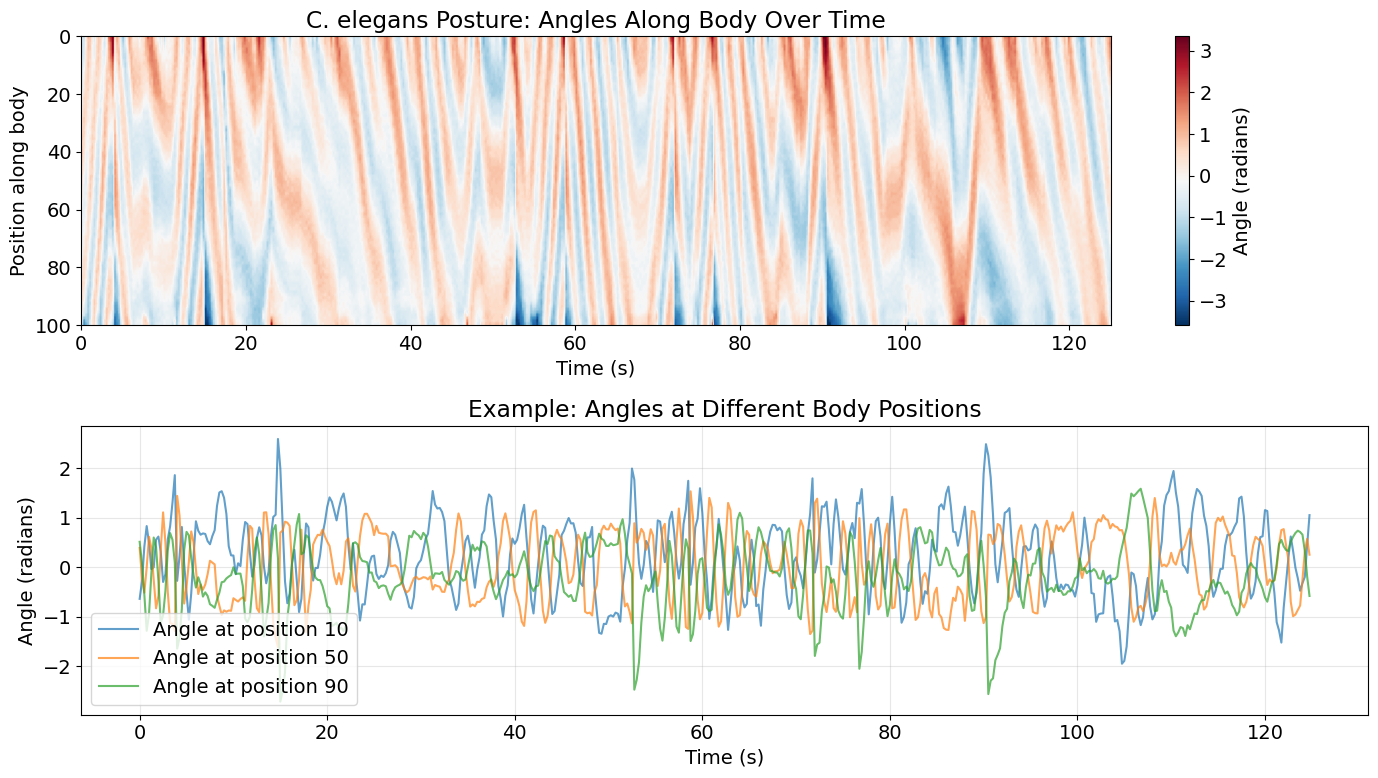

Notice the wave-like patterns traveling along the worm's body!


In [3]:
# Visualize angles over time as a heatmap
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Heatmap of angles
im = ax1.imshow(data[:500].T, aspect='auto', cmap='RdBu_r', 
                extent=[0, 500/frame_rate, D, 0])
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Position along body')
ax1.set_title('C. elegans Posture: Angles Along Body Over Time')
plt.colorbar(im, ax=ax1, label='Angle (radians)')

# Time series of a few angles
time = np.arange(500) / frame_rate
ax2.plot(time, data[:500, 10], label='Angle at position 10', alpha=0.7)
ax2.plot(time, data[:500, 50], label='Angle at position 50', alpha=0.7)
ax2.plot(time, data[:500, 90], label='Angle at position 90', alpha=0.7)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Angle (radians)')
ax2.set_title('Example: Angles at Different Body Positions')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice the wave-like patterns traveling along the worm's body!")

### Helper Function: Converting Angles to Positions

To visualize the worm's actual shape, we need to convert angles to (x,y) positions.

In [ ]:
def angle2pos(angles, segment_length=1.0):
    """
    Convert angles along the worm's body to (x,y) positions.
    
    Parameters:
    -----------
    angles : array (n_segments,)
        Angles along the worm's body (radians)
    segment_length : float
        Length of each segment (arbitrary units)
        
    Returns:
    --------
    positions : array (n_segments+1, 2)
        (x, y) coordinates of points along the worm
    """
    n = len(angles)
    positions = np.zeros((n + 1, 2))
    
    # Start at origin
    positions[0] = [0, 0]
    
    # Cumulative angles give orientation
    cumulative_angles = np.cumsum(angles)
    
    # TODO: Convert to (x,y) displacements 
    positions[1:, 0] = None # x-coordinates
    positions[1:, 1] = None # y-coordinates
    
    return positions

# Test the function
test_positions = angle2pos(data[0])
print(f"✓ Angle-to-position conversion working!")
print(f"  Input: {len(data[0])} angles")
print(f"  Output: {len(test_positions)} positions")

✓ Angle-to-position conversion working!
  Input: 100 angles
  Output: 101 positions


In [ ]:
# ## Solution for angle2pos function
# def angle2pos(angles, segment_length=1.0):
#     """
#     Convert angles along the worm's body to (x,y) positions.
    
#     Parameters:
#     -----------
#     angles : array (n_segments,)
#         Angles along the worm's body (radians)
#     segment_length : float
#         Length of each segment (arbitrary units)
        
#     Returns:
#     --------
#     positions : array (n_segments+1, 2)
#         (x, y) coordinates of points along the worm
#     """
#     n = len(angles)
#     positions = np.zeros((n + 1, 2))
    
#     # Start at origin
#     positions[0] = [0, 0]
    
#     # Cumulative angles give orientation
#     cumulative_angles = np.cumsum(angles)
    
#     # Convert to (x,y) displacements
#     positions[1:, 0] = segment_length * np.cumsum(np.cos(cumulative_angles))
#     positions[1:, 1] = segment_length * np.cumsum(np.sin(cumulative_angles))
    
#     return positions

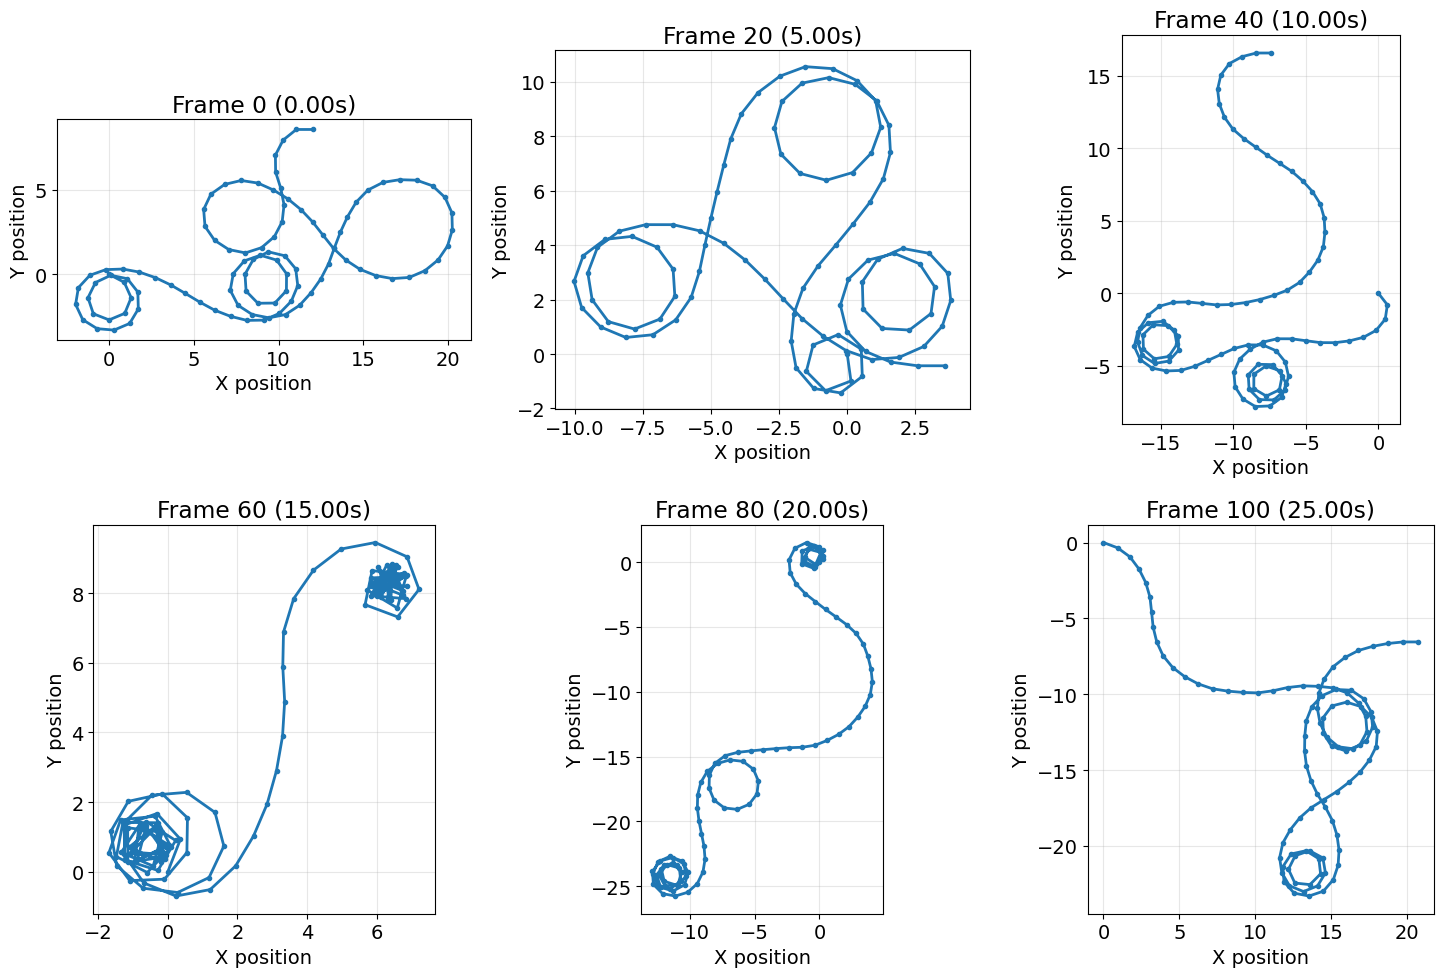

These are the actual worm shapes at different time points!


In [5]:
# Visualize the worm's shape at several time points
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

frames_to_show = [0, 20, 40, 60, 80, 100]

for i, frame in enumerate(frames_to_show):
    pos = angle2pos(data[frame])
    axes[i].plot(pos[:, 0], pos[:, 1], 'o-', linewidth=2, markersize=3)
    axes[i].set_aspect('equal')
    axes[i].set_title(f'Frame {frame} ({frame/frame_rate:.2f}s)')
    axes[i].grid(alpha=0.3)
    axes[i].set_xlabel('X position')
    axes[i].set_ylabel('Y position')

plt.tight_layout()
plt.show()

print("These are the actual worm shapes at different time points!")

---

## 🎯 Excercise Applying PCA to Worm Posture Data

Now let's perform PCA step-by-step to find the "eigenworms" - the principal modes of worm movement.

### PCA Procedure:

1. **Center the data** (subtract mean)
2. **Compute covariance matrix**:
3. **Find eigenvectors and eigenvalues**: 
4. **Sort by decreasing eigenvalue** (variance explained)
5. **Analyze the spectrum** to determine intrinsic dimensionality

Step 1: Data Centering
  Original data mean: 0.000000
  Centered data mean: 0.0000000000 (should be ~0)
  Shape: (6654, 100)
Step 2: Covariance Matrix
  Shape: (100, 100)
  This is a 100×100 matrix
  It captures how each angle co-varies with every other angle


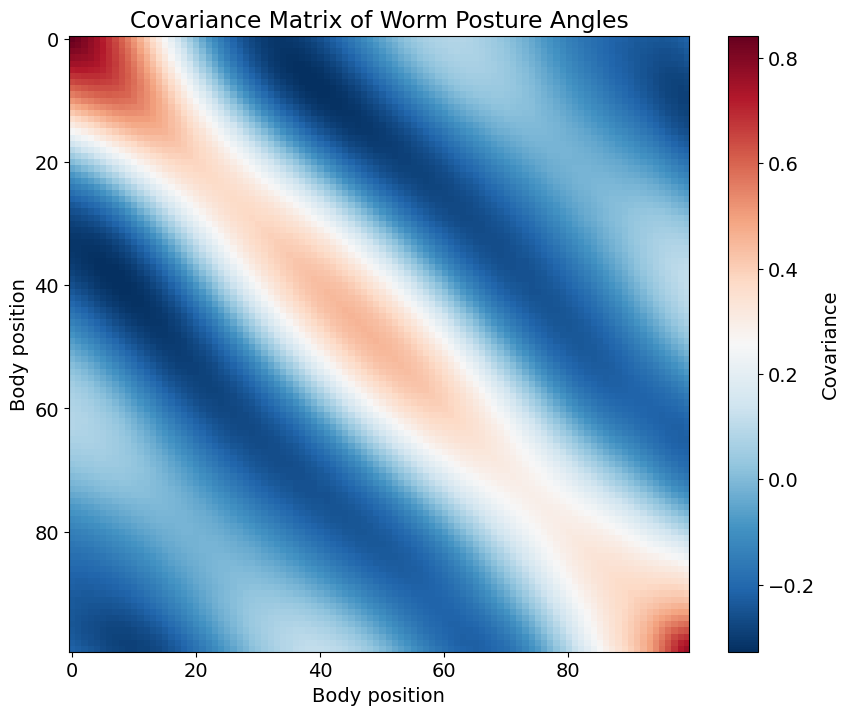


The diagonal shows variance of each angle.
Off-diagonal elements show how pairs of angles co-vary.


In [ ]:
# Step 1: Center the data
## TODO: center data from data 
x_cent = None

print("Step 1: Data Centering")
print(f"  Original data mean: {np.mean(data):.6f}")
print(f"  Centered data mean: {np.mean(x_cent):.10f} (should be ~0)")
print(f"  Shape: {x_cent.shape}")

## TODO: calculate covariance matrix of centered data
# Step 2: Compute covariance matrix
# Covariance matrix C = (1/(n-1)) * X^T * X
C = None

print("Step 2: Covariance Matrix")
print(f"  Shape: {C.shape}")
print(f"  This is a {C.shape[0]}×{C.shape[1]} matrix")
print(f"  It captures how each angle co-varies with every other angle")

# Visualize covariance matrix
plt.figure(figsize=(10, 8))
plt.imshow(C, cmap='RdBu_r', aspect='auto')
plt.colorbar(label='Covariance')
plt.title('Covariance Matrix of Worm Posture Angles')
plt.xlabel('Body position')
plt.ylabel('Body position')
plt.show()

print("\nThe diagonal shows variance of each angle.")
print("Off-diagonal elements show how pairs of angles co-vary.")


In [ ]:
## Solution for centering data and computing covariance matrix
# x_mean = np.mean(data, axis=0)  # Mean posture across all time points
# x_cent = data - x_mean
# C = (1 / (x_cent.shape[0] - 1)) * x_cent.T @ x_cent


In [ ]:
# Step 3: Compute eigenvectors and eigenvalues
## TODO: compute eigenvalues and eigenvectors of covariance matrix
eigenvalues, eigenvectors = None

# Step 4: Sort by descending eigenvalue
# eigh returns ascending order, so we reverse
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Step 3 & 4: Eigendecomposition")
print(f"  Number of eigenvalues: {len(eigenvalues)}")
print(f"  Largest eigenvalue: {eigenvalues[0]:.4f}")
print(f"  Smallest eigenvalue: {eigenvalues[-1]:.4e}")
print(f"\n  First 10 eigenvalues:")
for i in range(10):
    print(f"    λ{i+1} = {eigenvalues[i]:.4f}")

Step 3 & 4: Eigendecomposition
  Number of eigenvalues: 100
  Largest eigenvalue: 15.4031
  Smallest eigenvalue: 1.0322e-10

  First 10 eigenvalues:
    λ1 = 15.4031
    λ2 = 12.4894
    λ3 = 10.0068
    λ4 = 4.2522
    λ5 = 0.7615
    λ6 = 0.1684
    λ7 = 0.0743
    λ8 = 0.0416
    λ9 = 0.0278
    λ10 = 0.0227


In [ ]:
## Solution for computing eigenvalues and eigenvectors
# Step 2: Compute covariance matrix
# Covariance matrix C = (1/(n-1)) * X^T * X
# C = np.cov(x_cent.T)  # Note: np.cov expects features as rows

# # Step 3: Compute eigenvectors and eigenvalues
# eigenvalues, eigenvectors = np.linalg.eigh(C)

Step 3 & 4: Eigendecomposition
  Number of eigenvalues: 100
  Largest eigenvalue: 15.4031
  Smallest eigenvalue: 1.0322e-10

  First 10 eigenvalues:
    λ1 = 15.4031
    λ2 = 12.4894
    λ3 = 10.0068
    λ4 = 4.2522
    λ5 = 0.7615
    λ6 = 0.1684
    λ7 = 0.0743
    λ8 = 0.0416
    λ9 = 0.0278
    λ10 = 0.0227


### Explained Variance: How Many Dimensions Do We Really Need?

The **variance explained** by PC $k$ is:

$$\text{Variance Explained}_k = \frac{\lambda_k}{\sum_{i=1}^{D} \lambda_i}$$

The **cumulative variance explained** tells us how much total variance is captured by the first $K$ components:

$$\text{Cumulative Variance}_K = \frac{\sum_{k=1}^{K} \lambda_k}{\sum_{i=1}^{D} \lambda_i}$$

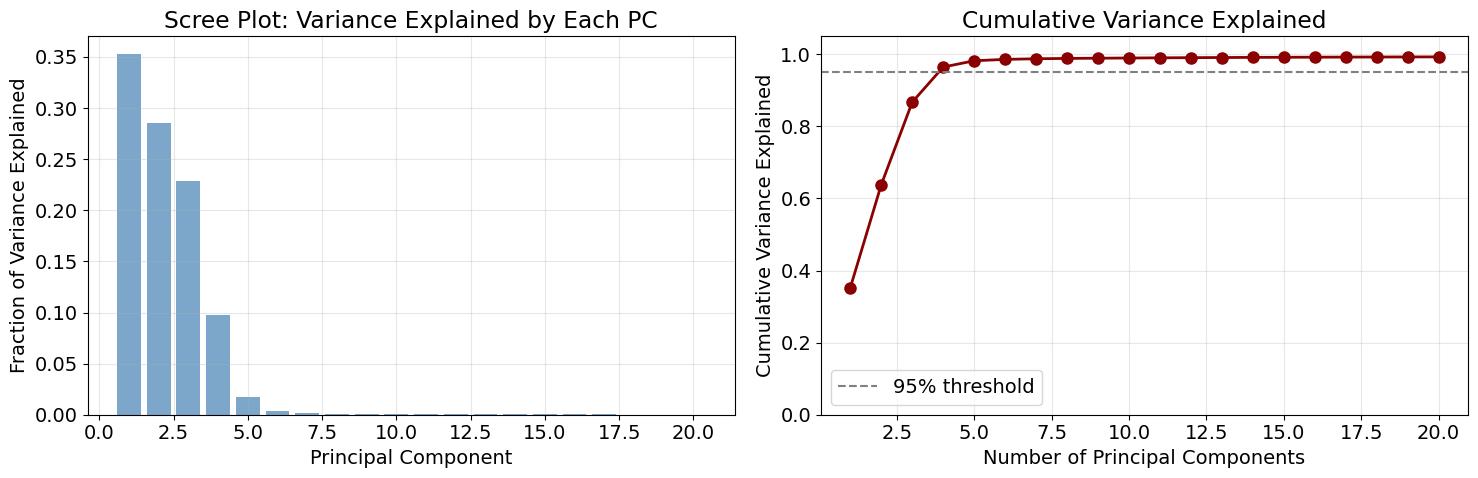


Key Statistics:
  First PC explains: 35.25% of variance
  First 2 PCs explain: 63.84% of variance
  First 4 PCs explain: 96.48% of variance
  First 10 PCs explain: 98.99% of variance

  PCs needed for 95% variance: 4

  ➜ From 100 dimensions down to ~4 dimensions!


In [ ]:
# Calculate variance explained
## TODO: calculate variance explained by each principal component
total_variance = None
variance_explained = None
cumulative_variance = np.cumsum(variance_explained)

# Plot scree plot and cumulative variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
ax1.bar(range(1, 21), variance_explained[:20], alpha=0.7, color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Fraction of Variance Explained')
ax1.set_title('Scree Plot: Variance Explained by Each PC')
ax1.grid(alpha=0.3)

# Cumulative variance
ax2.plot(range(1, 21), cumulative_variance[:20], 'o-', linewidth=2, 
         markersize=8, color='darkred')
ax2.axhline(y=0.95, color='gray', linestyle='--', label='95% threshold')
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Cumulative Variance Explained')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Print key statistics
print("\nKey Statistics:")
print(f"  First PC explains: {variance_explained[0]*100:.2f}% of variance")
print(f"  First 2 PCs explain: {cumulative_variance[1]*100:.2f}% of variance")
print(f"  First 4 PCs explain: {cumulative_variance[3]*100:.2f}% of variance")
print(f"  First 10 PCs explain: {cumulative_variance[9]*100:.2f}% of variance")

# Find number of PCs for 95% variance
n_pcs_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\n  PCs needed for 95% variance: {n_pcs_95}")
print(f"\n  ➜ From 100 dimensions down to ~{n_pcs_95} dimensions!")

In [ ]:
# ## Solution 
# total_variance = np.sum(eigenvalues)
# variance_explained = eigenvalues / total_variance
# cumulative_variance = np.cumsum(variance_explained)


### Interpreting the Results

**Remarkable finding:** Just **4 principal components** capture over 95% of the variance!

This means:
- The worm's posture, while technically 100-dimensional...
- ...can be accurately described with just **~4 numbers** at each time point
- The remaining 96 dimensions add very little information

**Biological Interpretation:**
- The worm's body is a connected, elastic structure
- Body segments cannot move completely independently
- There are only a few fundamental "modes" of body deformation
- These modes are captured by the principal components ("eigenworms")

---

## 1.4 Visualizing the "Eigenworms"

Let's look at what the first few principal components actually represent in terms of body shape.

Selected top 4 principal components
  PC matrix shape: (100, 4)
  These capture 96.48% of variance


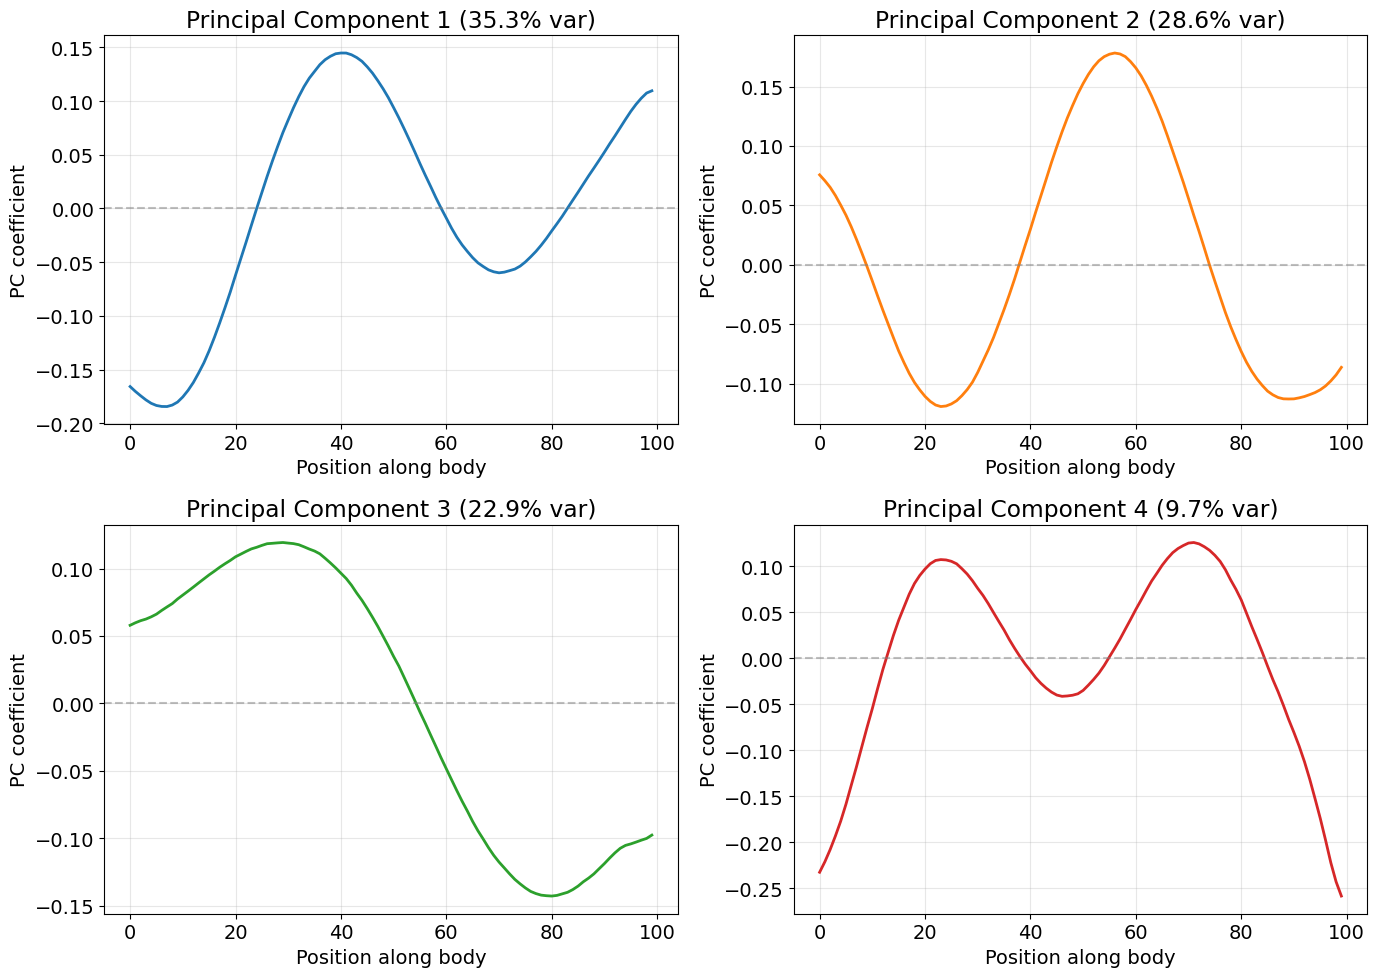


Interpretation:
  PC1: Captures the dominant undulation wave
  PC2: Captures a phase-shifted wave pattern
  PC3-4: Capture higher-order deformation modes


In [9]:
# Select the top K principal components to keep
K = 4  # Number of PCs to keep (you can adjust this based on variance explained)
PC = eigenvectors[:, :K]  # Shape: (100, 4)

print(f"Selected top {K} principal components")
print(f"  PC matrix shape: {PC.shape}")
print(f"  These capture {cumulative_variance[K-1]*100:.2f}% of variance")

# Visualize the eigenworms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(K):
    # Show the eigenvector as a function of body position
    axes[i].plot(PC[:, i], linewidth=2, color=f'C{i}')
    axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[i].set_xlabel('Position along body')
    axes[i].set_ylabel('PC coefficient')
    axes[i].set_title(f'Principal Component {i+1} '
                     f'({variance_explained[i]*100:.1f}% var)')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  PC1: Captures the dominant undulation wave")
print("  PC2: Captures a phase-shifted wave pattern")
print("  PC3-4: Capture higher-order deformation modes")

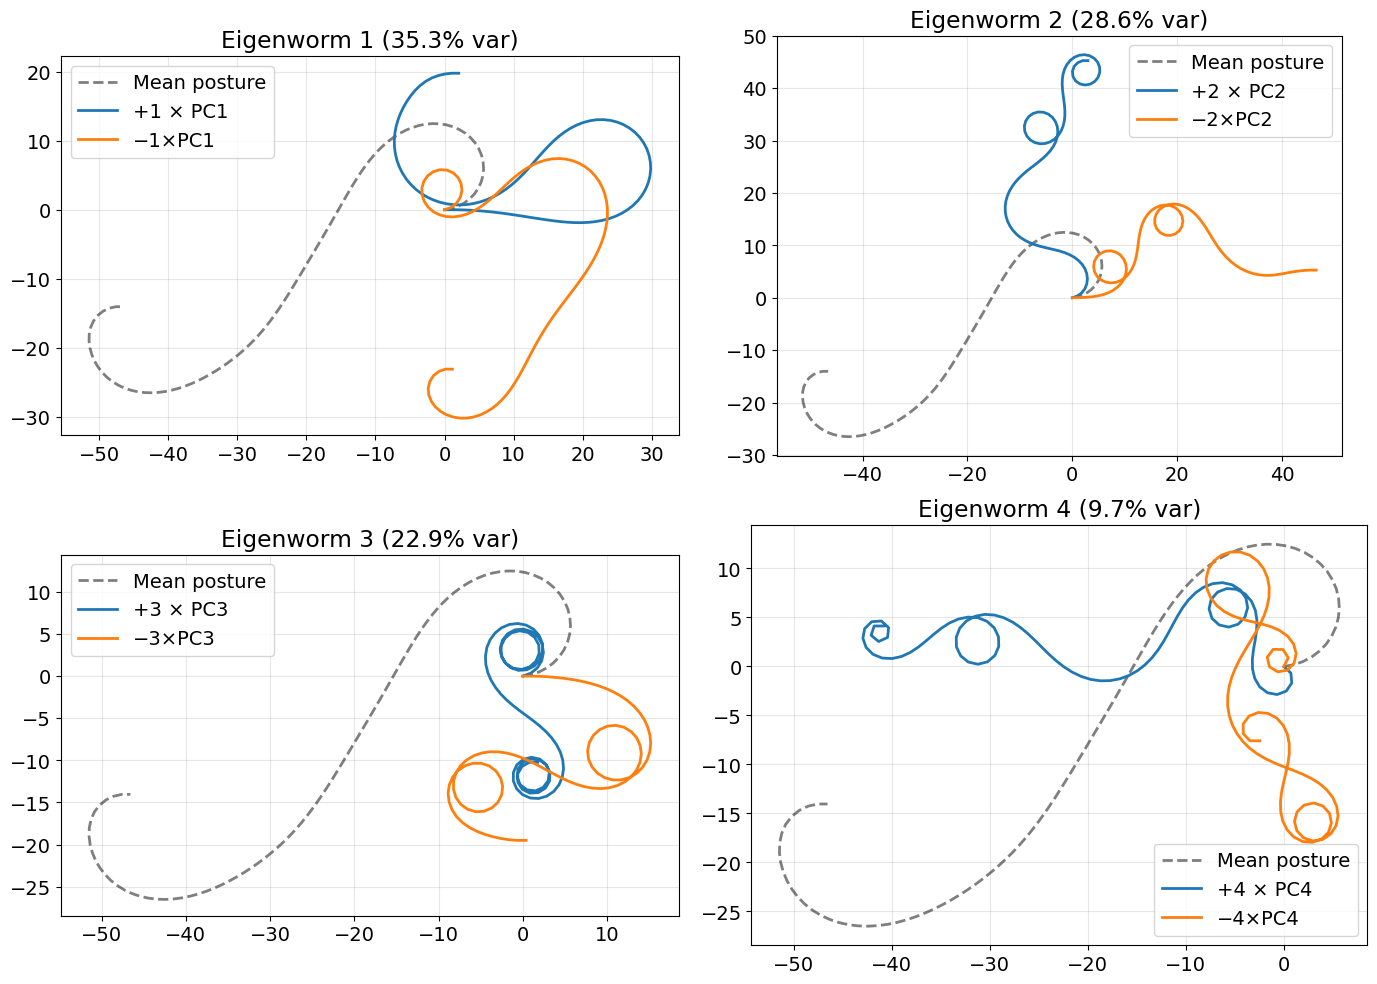

These show the characteristic body deformations for each eigenworm!


In [16]:
# Show what each eigenworm "mode" looks like as a body shape
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Scale factors for visualization
scale_factors = [1,2,3,4]

for i in range(K):
    # Create posture by adding scaled eigenvector to mean
    posture_plus = x_mean + scale_factors[i] * PC[:, i]
    posture_minus = x_mean - scale_factors[i] * PC[:, i]
    
    # Convert to positions
    pos_plus = angle2pos(posture_plus)
    pos_minus = angle2pos(posture_minus)
    pos_mean = angle2pos(x_mean)
    
    # Plot
    axes[i].plot(pos_mean[:, 0], pos_mean[:, 1], 'k--', 
                linewidth=2, alpha=0.5, label='Mean posture')
    axes[i].plot(pos_plus[:, 0], pos_plus[:, 1], 
                linewidth=2, label=f'+{scale_factors[i]} × PC{i+1}')
    axes[i].plot(pos_minus[:, 0], pos_minus[:, 1], 
                linewidth=2, label=f'−{scale_factors[i]}×PC{i+1}')
    axes[i].set_aspect('equal')
    axes[i].set_title(f'Eigenworm {i+1} '
                     f'({variance_explained[i]*100:.1f}% var)')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("These show the characteristic body deformations for each eigenworm!")

---

## 1.5 Projecting Data onto Principal Components

Now that we have the principal components, we can **project** our high-dimensional data onto this low-dimensional space.

**Projection formula:**
$$\mathbf{a} = X_c \cdot V$$

where:
- $X_c$ is centered data (n × 100)
- $V$ is PC matrix (100 × K)
- $\mathbf{a}$ is projected data (n × K) - these are the **PC scores** or **PC coefficients**

Each row of $\mathbf{a}$ is now a K-dimensional representation of the worm's posture at that time.

In [ ]:
# Project data onto principal components
# Shape: (N, K) --- TODO: compute projection of centered data onto top K PCs
x_project = None 
print(f"Projection complete!")
print(f"  Original data: {data.shape} (time × dimensions)")
print(f"  Projected data: {x_project.shape} (time × PCs)")
print(f"\n  Dimensionality reduced from {D} to {K}!")
print(f"\nFirst 5 time points in PC space:")
print(x_project[:5])

Projection complete!
  Original data: (6654, 100) (time × dimensions)
  Projected data: (6654, 4) (time × PCs)

  Dimensionality reduced from 100 to 4!

First 5 time points in PC space:
[[ 4.58230415 -0.54195284 -0.69538853  0.5519734 ]
 [ 1.41359957 -2.06768061  0.28740226  3.93410287]
 [-2.32045234 -0.80553002  0.83055157  2.71162587]
 [-3.53528505  2.79910877  2.26367625  1.70734262]
 [-0.25909162  3.65222824  3.3605916  -0.6032344 ]]


In [ ]:
# # Solution for projecting data onto principal components
# x_project = np.dot(x_cent, PC)  # Shape: (N, K)

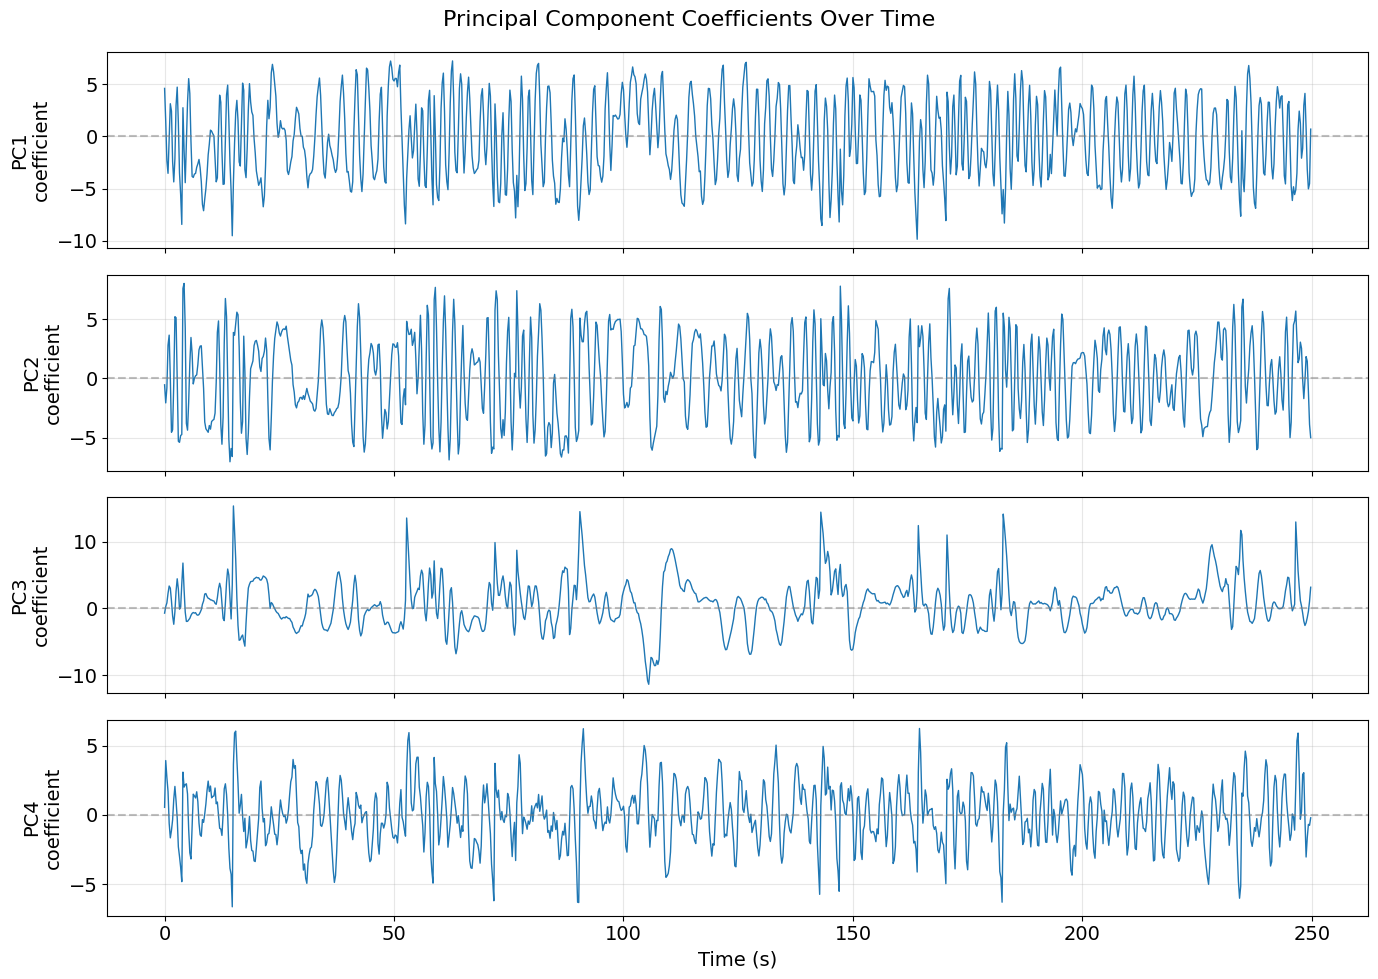

Notice the periodic/oscillatory patterns - these correspond to crawling waves!


In [18]:
# Plot PC coefficients over time
time = np.arange(N) / frame_rate

fig, axes = plt.subplots(K, 1, figsize=(14, 10))

for i in range(K):
    axes[i].plot(time[:1000], x_project[:1000, i], linewidth=1)
    axes[i].set_ylabel(f'PC{i+1}\ncoefficient')
    axes[i].grid(alpha=0.3)
    axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    if i < K-1:
        axes[i].set_xticklabels([])

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Principal Component Coefficients Over Time', fontsize=16)
plt.tight_layout()
plt.show()

print("Notice the periodic/oscillatory patterns - these correspond to crawling waves!")

---

## 1.6 Reconstructing Postures from PC Coefficients

Can we go back from the low-dimensional representation to the original postures?

**Reconstruction formula:**
$$\hat{X} = \mathbf{a} \cdot V^T + \bar{X}$$

where:
- $\mathbf{a}$ is projected data (n × K), explain how each eigenworm contribute over time
- $V^T$ is transposed PC matrix (K × 100), we take K eigenworm
- $\bar{X}$ is the mean posture
- $\hat{X}$ is reconstructed data (n × 100)

Let's see how well we can reconstruct the original worm shapes!

In [ ]:
# Reconstruct data from PC coefficients
## TODO: reconstruct data from projection using top K PCs
x_reconstruct = None

print(f"Reconstruction complete!")
print(f"  Reconstructed data shape: {x_reconstruct.shape}")
print(f"  Same as original: {x_reconstruct.shape == data.shape}")

# Calculate reconstruction error
reconstruction_error = np.mean((data - x_reconstruct)**2)
print(f"\n  Mean squared error: {reconstruction_error:.6f}")
print(f"  Relative error: {reconstruction_error / np.var(data) * 100:.2f}%")

Reconstruction complete!
  Reconstructed data shape: (6654, 100)
  Same as original: True

  Mean squared error: 0.015394
  Relative error: 3.43%


In [ ]:
# # Solution for reconstructing data from PC coefficients
# x_reconstruct = np.dot(x_project, PC.T) + x_mean

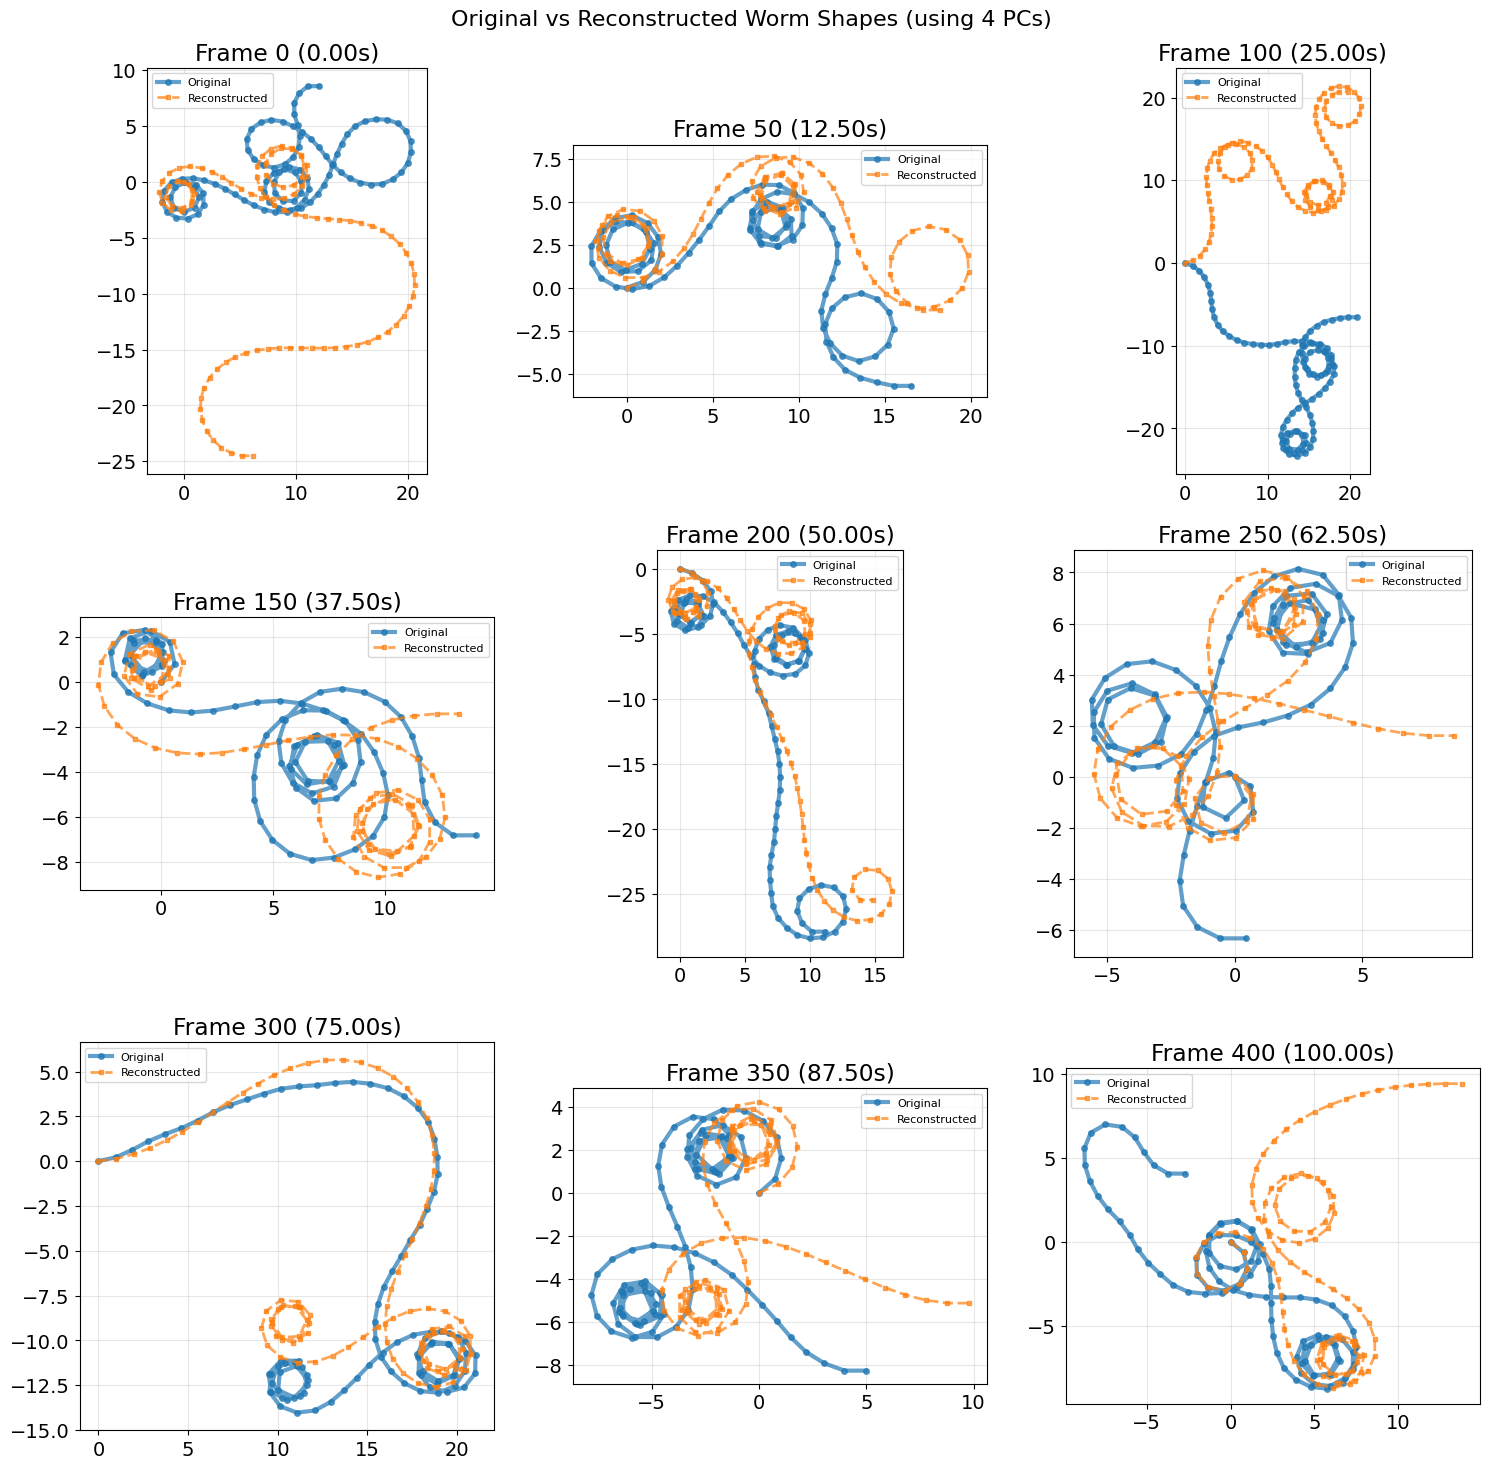


Remarkable! Using just 4 numbers instead of 100,
we can accurately reconstruct the worm's shape.


In [21]:
# Compare original vs reconstructed shapes
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

frames_to_compare = [0, 50, 100, 150, 200, 250, 300, 350, 400]

for i, frame in enumerate(frames_to_compare):
    pos_original = angle2pos(data[frame])
    pos_reconstruct = angle2pos(x_reconstruct[frame])
    
    axes[i].plot(pos_original[:, 0], pos_original[:, 1], 
                'o-', linewidth=3, markersize=4, alpha=0.7, label='Original')
    axes[i].plot(pos_reconstruct[:, 0], pos_reconstruct[:, 1], 
                's--', linewidth=2, markersize=3, alpha=0.7, label='Reconstructed')
    axes[i].set_aspect('equal')
    axes[i].set_title(f'Frame {frame} ({frame/frame_rate:.2f}s)')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle(f'Original vs Reconstructed Worm Shapes (using {K} PCs)', fontsize=16)
plt.tight_layout()
plt.show()

print(f"\nRemarkable! Using just {K} numbers instead of 100,")
print(f"we can accurately reconstruct the worm's shape.")

---

## 1.7 The "Phase Space" of Worm Behavior

One of the most revealing visualizations is to plot the first two PC coefficients against each other. This creates a **2D phase space** (or state space) representation of behavior.

### Why is this useful?

- Each point represents the worm's posture at one moment
- Nearby points = similar postures
- Trajectories through this space = behavioral sequences
- Geometric structure reveals **behavioral organization**

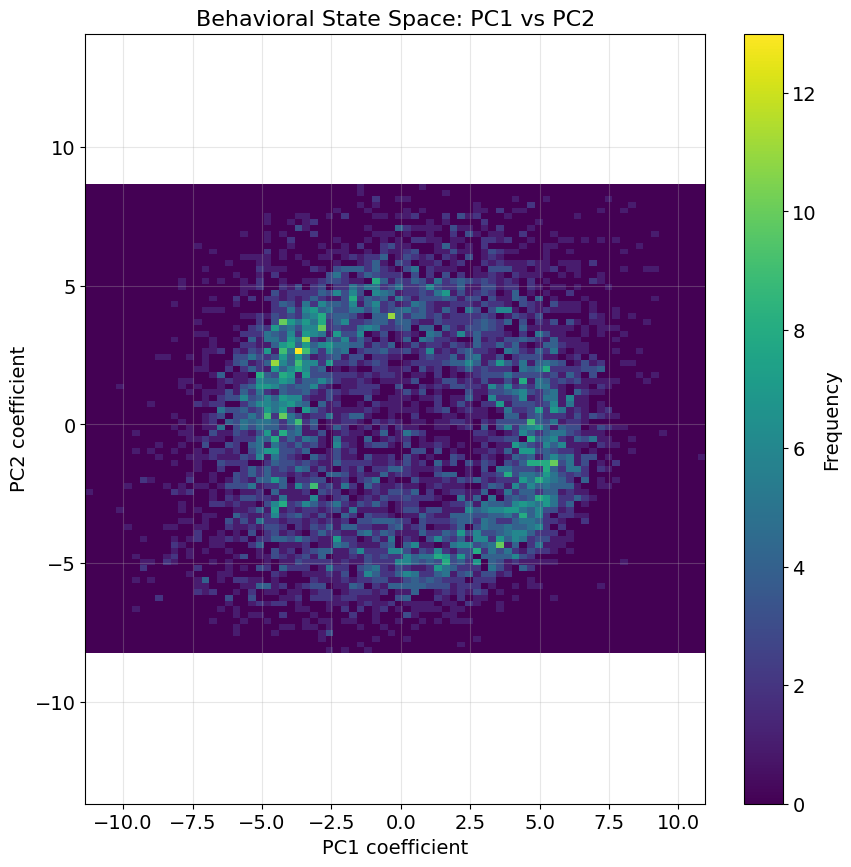


🔍 Key Observation: The famous 'RING' structure!

What does this tell us?
  • PC1 and PC2 form a circular/ring pattern
  • This reveals that crawling is a PERIODIC behavior
  • The worm moves around the ring as it crawls
  • Different positions on the ring = different phases of the crawling cycle

Biological interpretation:
  • The first two PCs capture a wave-like process
  • This wave propagates along the body during crawling
  • The ring shows the limit cycle of this oscillation


In [22]:
# Create 2D phase space plot
plt.figure(figsize=(10, 10))
plt.hist2d(x_project[:, 0], x_project[:, 1], bins=80, cmap='viridis')
plt.colorbar(label='Frequency')
plt.xlabel('PC1 coefficient', fontsize=14)
plt.ylabel('PC2 coefficient', fontsize=14)
plt.title('Behavioral State Space: PC1 vs PC2', fontsize=16)
plt.axis('equal')
plt.grid(alpha=0.3)
plt.show()

print("\n🔍 Key Observation: The famous 'RING' structure!")
print("\nWhat does this tell us?")
print("  • PC1 and PC2 form a circular/ring pattern")
print("  • This reveals that crawling is a PERIODIC behavior")
print("  • The worm moves around the ring as it crawls")
print("  • Different positions on the ring = different phases of the crawling cycle")
print("\nBiological interpretation:")
print("  • The first two PCs capture a wave-like process")
print("  • This wave propagates along the body during crawling")
print("  • The ring shows the limit cycle of this oscillation")

### Animating the Behavioral Dynamics

Let's create an animation showing how the worm moves through PC space while simultaneously showing its body shape!

In [31]:
# Animation parameters
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['animation.embed_limit'] = 2**64

## TODO: choose start and end frames for animation
start = 0
end = 100
time_anim = np.arange(0, N/frame_rate, 1/frame_rate)

# Create figure with subplots
fig, axes = plt.subplot_mosaic("ABD;CBD", figsize=(15, 5))

# PC1 time series (top left)
pA1, = axes["A"].plot(time_anim, x_project[:, 0], color="g", linewidth=1)
pA2, = axes["A"].plot(time_anim[start], x_project[start, 0], 
                      color="k", marker="o", markersize=8)
axes["A"].set_xlim([start/frame_rate, end/frame_rate])
axes["A"].set_title("PC1 coefficient")
axes["A"].set_ylabel("PC1")
axes["A"].grid(alpha=0.3)
axes["A"].xaxis.set_visible(False)

# PC2 time series (bottom left)
pC1, = axes["C"].plot(time_anim, x_project[:, 1], color="b", linewidth=1)
pC2, = axes["C"].plot(time_anim[start], x_project[start, 1], 
                      color="k", marker="o", markersize=8)
axes["C"].set_xlim([start/frame_rate, end/frame_rate])
axes["C"].set_title("PC2 coefficient")
axes["C"].set_xlabel("Time (s)")
axes["C"].set_ylabel("PC2")
axes["C"].grid(alpha=0.3)

# Worm shape (right)
pos_original = angle2pos(data[start])
pos_reconstruct = angle2pos(x_reconstruct[start])
pD2, = axes["D"].plot(pos_original[:, 0], pos_original[:, 1], 
                      marker=".", label="Original", 
                      linewidth=6, markersize=15, alpha=0.6)
pD1, = axes["D"].plot(pos_reconstruct[:, 0], pos_reconstruct[:, 1], 
                      marker=".", label="Reconstructed", 
                      linewidth=6, markersize=15)

axes["D"].axis("equal")
axes['D'].set_xlim(-40, 40)
axes["D"].set_ylim(-40, 40)
axes["D"].legend()
axes["D"].set_title("Worm Shape")
axes["D"].grid(alpha=0.3)

# Phase space (center)
axes["B"].hist2d(x_project[:, 0], x_project[:, 1], bins=80, cmap='gray_r')
pB2, = axes["B"].plot(x_project[start, 0], x_project[start, 1], 
                      marker="o", color="red", markersize=10)
axes["B"].axis("equal")
axes["B"].set_xlabel("PC1")
axes["B"].set_ylabel("PC2")
axes["B"].set_title("Behavioral State Space")
axes["B"].grid(alpha=0.3)

def animate(t):
    """Update function for animation."""
    # Update time series markers
    pA2.set_data([time_anim[t]], [x_project[t, 0]])
    pC2.set_data([time_anim[t]], [x_project[t, 1]])
    
    # Update worm shapes
    pos_original = angle2pos(data[t])
    pos_reconstruct = angle2pos(x_reconstruct[t])
    pD2.set_data(pos_original[:, 0], pos_original[:, 1])
    pD1.set_data(pos_reconstruct[:, 0], pos_reconstruct[:, 1])
    
    # Update phase space marker
    pB2.set_data([x_project[t, 0]], [x_project[t, 1]])
    
    return (pA2, pC2, pD1, pD2, pB2)

mov = FuncAnimation(fig, animate, frames=range(start+1, end), 
                   interval=250, blit=True)
plt.close()

print("Animation created! Displaying...")

Animation created! Displaying...


### What to observe in the animation:

1. **PC time series (left)**: Watch the oscillatory patterns in PC1 and PC2
2. **Worm shape (right)**: See how the body undulates during crawling
3. **Phase space (center)**: The red dot moves around the ring!

**Key Insight:** The trajectory through PC space is periodic, matching the cyclic nature of crawling behavior. This is a beautiful example of how dimensionality reduction reveals the underlying structure of complex behavior.

---

In [ ]:
# Display the animation
HTML(mov.to_jshtml())

## Part 1 Summary

### What we learned:

1. **High-dimensional behavioral data** (100 angles) can be reduced to low-dimensional representations (4 PCs)

2. **PCA identifies eigenworms** - fundamental modes of body deformation

3. **Reconstruction from PCs** is remarkably accurate

4. **Phase space visualization** reveals behavioral structure:
   - Ring topology indicates periodic behavior
   - Points on the ring = different phases of crawling cycle

5. **Biological interpretation**:
   - Only ~4 independent modes control worm posture
   - Body constraints reduce effective dimensionality
   - These modes correspond to traveling waves along the body

### Why this matters:

- **Data compression**: Store and analyze behavior efficiently
- **Feature extraction**: Use PC coefficients for further analysis
- **Behavioral comparison**: Compare across individuals, conditions, genotypes
- **Theoretical understanding**: Reveals fundamental behavioral organization

---

# Part 2: State-Space Reconstruction and the Maximum Predictability Principle

## Motivation

In Part 1, we used PCA to find a low-dimensional representation of worm posture. But there's a deeper question:

**What if we only measured ONE variable (say, just one angle along the body)?**

Could we still reconstruct the full behavioral state space?

The answer is YES - using a technique called **delay embedding**!

## Key Concepts

### State Space
A **state space** is a mathematical space where each point represents a complete description of the system at a moment in time. For the worm:
- Could be all 100 angles
- Could be the PC coefficients  
- Could be reconstructed from a single measurement!

### Takens' Theorem (Delay Embedding)
**Key idea:** For a dynamical system, you can reconstruct the full state space from a single time series by using **time delays**.

Instead of just $x(t)$, use:
$$\mathbf{y}(t) = [x(t), x(t-\tau), x(t-2\tau), ..., x(t-(d-1)\tau)]$$

where:
- $\tau$ is the **time delay**
- $d$ is the **embedding dimension**

### Maximum Predictability Principle
But how do we choose $\tau$ and $d$? 

The **Maximum Predictability Principle** ([Costa et al., 2023](https://doi.org/10.1063/5.0129398)) says:
**Choose the embedding that makes the future most predictable from the present!**

This is measured by the **Lyapunov exponent** - a quantification of how quickly nearby trajectories diverge.

---

## 2.1 Demonstration with the Lorenz System

Before applying to worm data, let's understand these concepts with a classic dynamical system: the **Lorenz attractor**.

### The Lorenz System

The Lorenz system is a set of three differential equations that exhibit chaotic behavior:

$$\frac{dx}{dt} = \sigma (y - x)$$
$$\frac{dy}{dt} = x (\rho - z) - y$$
$$\frac{dz}{dt} = x y - \beta z$$

Despite having only 3 variables and simple equations, it shows complex, unpredictable behavior - perfect for testing state-space methods!

In [ ]:
# Define Lorenz system
def Lorenz(state, t, sigma, rho, beta):
    """Lorenz system differential equations."""
    x, y, z = state
    xd = sigma * (y - x)
    yd = (rho - z) * x - y
    zd = x * y - beta * z
    return [xd, yd, zd]

# Simulation parameters
dt = 0.02
T = 500
state0 = np.array([-10, -22, 27])
t = np.linspace(0, T, int(T/dt))
sigma, rho, beta = 10, 28, 8/3

# Solve the system
tseries = np.array(odeint(Lorenz, state0, t, args=(sigma, rho, beta)), 
                   dtype=np.float64)

print(f"Lorenz system simulated!")
print(f"  Duration: {T} time units")
print(f"  Time step: {dt}")
print(f"  Data points: {len(tseries)}")
print(f"  Variables: x, y, z")

In [ ]:
# Plot time series
plt.figure(figsize=(14, 4))
plt.plot(t[:1000], tseries[:1000], linewidth=1)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(['x', 'y', 'z'], fontsize=12)
plt.title('Lorenz System: Time Series (first 1000 points)', fontsize=14)
plt.grid(alpha=0.3)
plt.show()

print("Complex, seemingly random fluctuations - hallmark of chaos!")

In [ ]:
# Plot 3D state space
fig = go.Figure(data=[go.Scatter3d(
    x=tseries[:10000, 0],
    y=tseries[:10000, 1],
    z=tseries[:10000, 2],
    mode='lines',
    line=dict(width=1, color='blue')
)])

fig.update_layout(
    title='Lorenz Attractor in 3D State Space',
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z'
    ),
    showlegend=False
)

plotly.offline.iplot(fig)

print("\nThe famous 'butterfly' shape of the Lorenz attractor!")
print("Notice the beautiful structure hidden in the chaotic time series.")

### Delay Embedding Example

Now let's see if we can reconstruct this 3D structure using only the $x$ variable with delay embedding!

In [ ]:
# Function to create delay embedding
def delay_embed(x, tau, dim):
    """
    Create delay embedding of a time series.
    
    Parameters:
    -----------
    x : array (n_timepoints,)
        Time series data
    tau : int
        Time delay (in number of samples)
    dim : int
        Embedding dimension
        
    Returns:
    --------
    embedded : array (n_timepoints - (dim-1)*tau, dim)
        Delay-embedded time series
    """
    n = len(x) - (dim - 1) * tau
    embedded = np.zeros((n, dim))
    
    for i in range(dim):
        embedded[:, i] = x[i*tau : i*tau + n]
    
    return embedded

# Create delay embedding of x component only
tau = 8  # delay in time steps
dim = 3  # embedding dimension

x_only = tseries[:, 0]  # Just the x variable
embedded = delay_embed(x_only, tau, dim)

print(f"Delay embedding created!")
print(f"  Original time series: {len(x_only)} points")
print(f"  Embedding dimension: {dim}")
print(f"  Time delay (τ): {tau} steps = {tau*dt:.2f} time units")
print(f"  Embedded data shape: {embedded.shape}")
print(f"\nFirst 5 embedded points:")
print(embedded[:5])

In [ ]:
# Plot reconstructed attractor
fig = go.Figure(data=[go.Scatter3d(
    x=embedded[:10000, 0],
    y=embedded[:10000, 1],
    z=embedded[:10000, 2],
    mode='lines',
    line=dict(width=1, color='red')
)])

fig.update_layout(
    title='Reconstructed Attractor from Delay Embedding (x variable only!)',
    scene=dict(
        xaxis_title='x(t)',
        yaxis_title=f'x(t-{tau*dt:.2f})',
        zaxis_title=f'x(t-{2*tau*dt:.2f})'
    ),
    showlegend=False
)

plotly.offline.iplot(fig)

print("\n🎉 Amazing! We reconstructed the attractor from just ONE variable!")
print("This demonstrates the power of delay embedding.")

---

## 2.2 Lyapunov Exponent: Quantifying Predictability

The **Lyapunov exponent** ($\lambda$) measures how quickly nearby trajectories in state space diverge:

$$\lambda = \lim_{t\to\infty} \frac{1}{t} \ln\frac{||\delta(t)||}{||\delta(0)||}$$

where $\delta(t)$ is the separation between two initially nearby trajectories.

**Interpretation:**
- $\lambda < 0$: Trajectories converge (stable, predictable)
- $\lambda = 0$: Neutral stability
- $\lambda > 0$: Trajectories diverge (chaotic, unpredictable)

### Maximum Predictability Principle

**The best embedding minimizes the Lyapunov exponent!**

Why? Because we want:
- Nearby states to stay nearby
- The future to be maximally predictable from the present
- The least sensitivity to initial conditions

This is beautifully explained in [Costa et al., 2023](https://doi.org/10.1063/5.0129398) and applied to C. elegans behavior.

---

## 2.3 Application to C. elegans: Finding the Optimal Embedding

Now let's apply these concepts to our worm data!

In the groundbreaking paper by [Ahamed, Costa & Stephens, 2021](https://doi.org/10.1038/s41567-020-01036-8), the authors:

1. Started with PC coefficients from the posture data
2. Applied delay embedding to each PC
3. Used the Maximum Predictability Principle to find optimal embedding parameters
4. Discovered a maximally predictive state space for worm behavior

Let's implement a simplified version of this analysis.

### Conceptual Workflow

```
Raw posture (100D) 
    ↓
PCA → PC coefficients (4D)
    ↓
Delay embedding → State space (4 × embedding_dim D)
    ↓
Optimize (τ, dim) to minimize Lyapunov exponent
    ↓
Maximally Predictive State Space!
```

### Why this matters:

- Captures **temporal dependencies** (not just instantaneous posture)
- Reveals **behavioral dynamics** (how states flow into each other)
- Enables **better clustering** (similar behavioral sequences group together)
- Provides **mechanistic insight** (what information is needed to predict behavior)

---

## Exercise: Create Delay-Embedded State Space

Let's create a simple delay-embedded version of our PC space.

In [ ]:
# =============================================================================
# EXERCISE: Create delay embedding of PC coefficients
# =============================================================================
# TODO: Apply delay embedding to each of the 4 PCs
# HINT: Use the delay_embed function we defined earlier
# HINT: Choose reasonable values for tau and dim (try tau=5, dim=3)
# HINT: You'll need to stack the embedded versions of each PC

# For demonstration, we'll show a simpler version:
tau_worm = 5  # delay in frames (5 frames = 1.25 seconds at 4 fps)
dim_worm = 3  # embedding dimension

# Embed each PC separately
embedded_pcs = []
for i in range(K):
    pc_embedded = delay_embed(x_project[:, i], tau_worm, dim_worm)
    embedded_pcs.append(pc_embedded)

# Stack all embedded PCs
state_space = np.hstack(embedded_pcs)

print(f"Delay-embedded state space created!")
print(f"  Original PC space: {x_project.shape}")
print(f"  Embedded state space: {state_space.shape}")
print(f"  Each PC embedded in {dim_worm}D with delay τ={tau_worm}")
print(f"  Total dimensionality: {K} PCs × {dim_worm} delays = {state_space.shape[1]}D")

In [ ]:
# Visualize the first 3 dimensions of the embedded state space
fig = go.Figure(data=[go.Scatter3d(
    x=state_space[:5000, 0],
    y=state_space[:5000, 1],
    z=state_space[:5000, 2],
    mode='markers',
    marker=dict(
        size=2,
        color=np.arange(5000),
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Time")
    )
)])

fig.update_layout(
    title='Delay-Embedded State Space (first 3 dimensions)',
    scene=dict(
        xaxis_title='PC1(t)',
        yaxis_title=f'PC1(t-{tau_worm})',
        zaxis_title=f'PC1(t-{2*tau_worm})'
    )
)

plotly.offline.iplot(fig)

print("\nNotice how the trajectory flows through state space!")
print("Color represents time - you can see the temporal structure.")

---

## Part 2 Summary

### Key Concepts:

1. **Delay Embedding (Takens' Theorem)**:
   - Can reconstruct full state space from a single variable
   - Uses time-delayed copies: [x(t), x(t-τ), x(t-2τ), ...]
   - Powerful technique for analyzing dynamical systems

2. **Lyapunov Exponent**:
   - Quantifies predictability/chaos
   - Measures how fast nearby trajectories diverge
   - Positive = chaotic, negative = stable

3. **Maximum Predictability Principle**:
   - Choose embedding parameters to minimize Lyapunov exponent
   - Maximize short-term predictability
   - Reveals optimal representation of behavioral dynamics

4. **Application to C. elegans**:
   - Start with PC coefficients (from Part 1)
   - Apply delay embedding
   - Get higher-dimensional but more informative state space
   - Captures temporal dependencies, not just instantaneous posture

### Why This Matters:

- **Reveals hidden structure** in behavioral dynamics
- **Improves prediction** of future behavior
- **Enables better clustering** of behavioral sequences
- **Provides mechanistic insight** into behavioral organization

### Connections to Day 5:

This maximally predictive state space is exactly what we'll use tomorrow for:
- Clustering into discrete behavioral states
- Building Markov transition matrices
- Discovering behavioral grammars
- Understanding hierarchical organization

---

# Overall Tutorial Summary

## What We Accomplished

### Part 1: Dimensionality Reduction with PCA
✓ Reduced worm posture from 100D to 4D  
✓ Discovered "eigenworms" - fundamental movement modes  
✓ Visualized behavioral phase space (the famous ring!)  
✓ Reconstructed accurate postures from low-D representation  

### Part 2: State-Space Reconstruction
✓ Understood delay embedding and Takens' theorem  
✓ Learned about Lyapunov exponents and predictability  
✓ Applied Maximum Predictability Principle  
✓ Created temporally-enriched state space  

## The Big Picture

We've developed a powerful pipeline for analyzing behavioral data:

```
Raw Data (high-D, noisy)
    ↓
Dimensionality Reduction (PCA)
    ↓
Low-D representation (interpretable)
    ↓
Delay Embedding (capture dynamics)
    ↓
Maximally Predictive State Space
    ↓
Ready for clustering, Markov models, etc.!
```

## Key Takeaways

1. **Behavior is lower-dimensional than it appears** - body constraints reduce dimensionality
2. **Spatial structure reveals behavioral organization** - ring topology indicates periodic behavior
3. **Temporal dependencies matter** - need delays to capture dynamics
4. **Predictability is a guiding principle** - optimize representations for prediction
5. **Multiple time scales exist** - from sub-second postures to longer sequences

## Connections to Neuroscience

These methods help us understand:
- How neural circuits generate coordinated behavior
- What information is represented in the nervous system
- How motor patterns emerge from low-dimensional control
- The relationship between neural dynamics and behavioral dynamics

## Further Reading

**Key Papers:**
1. Stephens et al., 2008 - Original eigenworms paper ([link](https://doi.org/10.1371/journal.pcbi.1000028))
2. Ahamed, Costa & Stephens, 2021 - Maximum predictability ([link](https://doi.org/10.1038/s41567-020-01036-8))
3. Costa et al., 2023 - Theory of maximally predictive states ([link](https://doi.org/10.1063/5.0129398))
4. Costa et al., 2024 - Markovian dynamics across scales ([link](https://doi.org/10.1073/pnas.2318805121))

**Textbooks:**
- Strogatz - Nonlinear Dynamics and Chaos
- Abarbanel - Analysis of Observed Chaotic Data

---

## Next Steps

In tomorrow's tutorial, we'll:
1. Cluster the state space into discrete behavioral states
2. Build transition matrices between states
3. Analyze behavioral grammars and hierarchical organization
4. Apply Hidden Markov Models
5. Connect to the Berman 2016 framework

**Congratulations on completing this tutorial!** 🎉

---

## Acknowledgments

This tutorial is adapted from materials developed by:
- BingKan Xue (University of Florida) - PCA/Eigenworms section
- OIST Physics of Behavior Tutorial Series - State-space analysis
- Original source: https://github.com/oist/Physics-of-Behavior-Tutorials

Based on groundbreaking research by the Stephens Lab and collaborators.
